# Bloch Sphere Visualization ⚛️

The **Bloch sphere** is a geometric representation of the state of a single qubit.

It provides an intuitive way to visualize quantum states and understand how quantum gates transform those states.

A general single-qubit pure state can be written as:

$$
|\psi\rangle =
\cos\left(\frac{\theta}{2}\right)|0\rangle
+
e^{i\phi}
\sin\left(\frac{\theta}{2}\right)|1\rangle
$$

where:

- $\theta$ is the polar angle.
- $\phi$ is the azimuthal angle.

Every pure single-qubit state can therefore be represented by a point on the surface of the Bloch sphere.

## States explored in this notebook

We will visualize:

- $|0\rangle$ — north pole
- $|1\rangle$ — south pole
- $|+\rangle$ — positive X-axis
- $|-\rangle$ — negative X-axis

We will also create these states using Qiskit circuits and inspect their statevectors.

In [17]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_vector
import matplotlib.pyplot as plt
from IPython.display import display

## 1. The Bloch Sphere Coordinate System

The Bloch sphere uses three axes:

- **X-axis**
- **Y-axis**
- **Z-axis**

The computational basis states are located on the Z-axis:

$$
|0\rangle \rightarrow +Z
$$

$$
|1\rangle \rightarrow -Z
$$

The equal superposition states are located on the X-axis:

$$
|+\rangle =
\frac{|0\rangle + |1\rangle}{\sqrt{2}}
\rightarrow +X
$$

$$
|-\rangle =
\frac{|0\rangle - |1\rangle}{\sqrt{2}}
\rightarrow -X
$$

In [18]:
# Bloch vectors of important single-qubit states

states = {
    "|0>": [0, 0, 1],
    "|1>": [0, 0, -1],
    "|+>": [1, 0, 0],
    "|->": [-1, 0, 0],
}

print("Bloch Vectors:")

for state_name, vector in states.items():
    print(f"{state_name}: {vector}")

Bloch Vectors:
|0>: [0, 0, 1]
|1>: [0, 0, -1]
|+>: [1, 0, 0]
|->: [-1, 0, 0]


## 2. Visualizing the $|0\rangle$ State

The state $|0\rangle$ is located at the **north pole** of the Bloch sphere.

Its Bloch vector is:

$$
(0,0,1)
$$

This corresponds to the positive Z-axis.

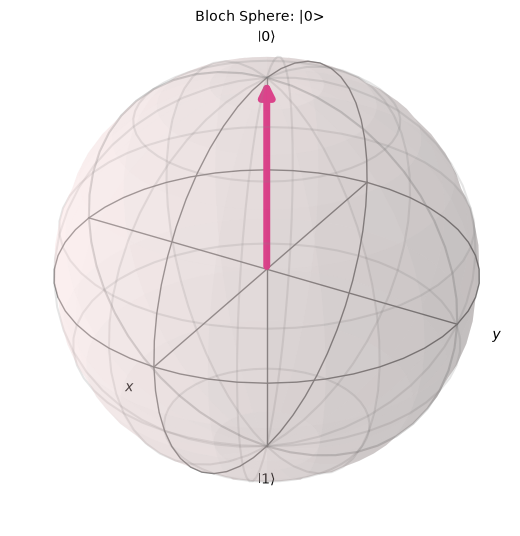

In [19]:
fig = plot_bloch_vector(
    states["|0>"],
    title="Bloch Sphere: |0>"
)

display(fig)

## 3. Visualizing the $|1\rangle$ State

The state $|1\rangle$ is located at the **south pole**.

Its Bloch vector is:

$$
(0,0,-1)
$$

This is opposite to the $|0\rangle$ state.

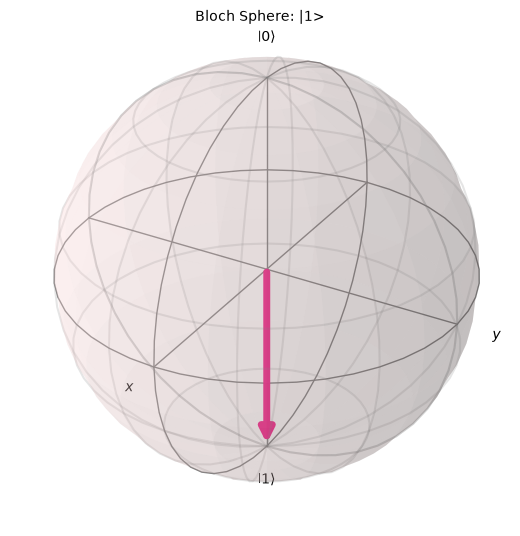

In [20]:
fig = plot_bloch_vector(
    states["|1>"],
    title="Bloch Sphere: |1>"
)

display(fig)

## 4. Visualizing the $|+\rangle$ State

The state:

$$
|+\rangle =
\frac{|0\rangle + |1\rangle}{\sqrt{2}}
$$

is located along the **positive X-axis**.

Its Bloch vector is:

$$
(1,0,0)
$$

This is the state produced when the Hadamard gate is applied to $|0\rangle$.

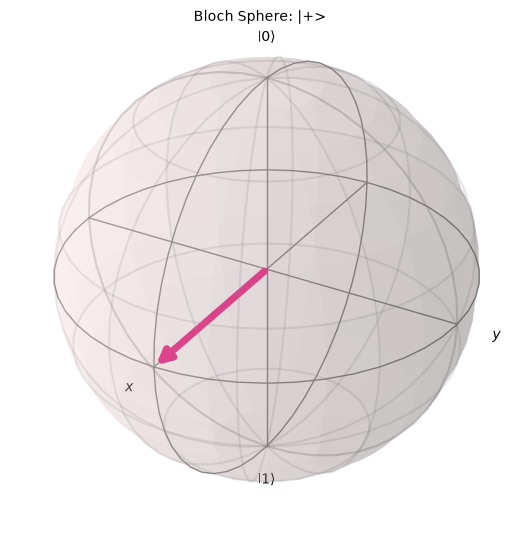

In [21]:
fig = plot_bloch_vector(
    states["|+>"],
    title="Bloch Sphere: |+>"
)

display(fig)

## 5. Visualizing the $|-\rangle$ State

The state:

$$
|-\rangle =
\frac{|0\rangle - |1\rangle}{\sqrt{2}}
$$

is located along the **negative X-axis**.

Its Bloch vector is:

$$
(-1,0,0)
$$

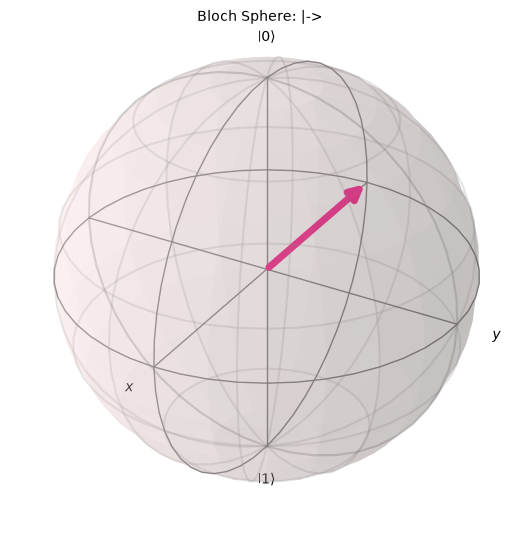

In [22]:
fig = plot_bloch_vector(
    states["|->"],
    title="Bloch Sphere: |->"
)

display(fig)

## 6. Creating $|0\rangle$ Using Qiskit

A newly initialized single-qubit circuit represents the state:

$$
|0\rangle
$$

We can verify this using the `Statevector` class.

In [23]:
zero_circuit = QuantumCircuit(1)

zero_state = Statevector.from_instruction(
    zero_circuit
)

print("Circuit:")
print(zero_circuit.draw())

print("\nStatevector:")
print(zero_state)

Circuit:
   
q: 
   

Statevector:
Statevector([1.+0.j, 0.+0.j],
            dims=(2,))


## 7. Creating $|1\rangle$ Using the X Gate

The X gate transforms:

$$
|0\rangle \rightarrow |1\rangle
$$

We can verify the resulting statevector using Qiskit.

In [24]:
one_circuit = QuantumCircuit(1)

one_circuit.x(0)

one_state = Statevector.from_instruction(
    one_circuit
)

print("Circuit:")
print(one_circuit.draw())

print("\nStatevector:")
print(one_state)

Circuit:
   ┌───┐
q: ┤ X ├
   └───┘

Statevector:
Statevector([0.+0.j, 1.+0.j],
            dims=(2,))


## 8. Creating $|+\rangle$ Using the Hadamard Gate

The Hadamard gate transforms $|0\rangle$ into:

$$
|+\rangle =
\frac{|0\rangle + |1\rangle}{\sqrt{2}}
$$

The resulting statevector should contain two equal amplitudes.

In [25]:
plus_circuit = QuantumCircuit(1)

plus_circuit.h(0)

plus_state = Statevector.from_instruction(
    plus_circuit
)

print("Circuit:")
print(plus_circuit.draw())

print("\nStatevector:")
print(plus_state)

Circuit:
   ┌───┐
q: ┤ H ├
   └───┘

Statevector:
Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))


## 9. Creating $|-\rangle$

The state $|-\rangle$ is:

$$
|-\rangle =
\frac{|0\rangle - |1\rangle}{\sqrt{2}}
$$

One way to create it is to first apply the X gate and then the Hadamard gate:

$$
|0\rangle
\xrightarrow{X}
|1\rangle
\xrightarrow{H}
|-\rangle
$$

In [26]:
minus_circuit = QuantumCircuit(1)

minus_circuit.x(0)
minus_circuit.h(0)

minus_state = Statevector.from_instruction(
    minus_circuit
)

print("Circuit:")
print(minus_circuit.draw())

print("\nStatevector:")
print(minus_state)

Circuit:
   ┌───┐┌───┐
q: ┤ X ├┤ H ├
   └───┘└───┘

Statevector:
Statevector([ 0.70710678+0.j, -0.70710678+0.j],
            dims=(2,))


# Summary ⚛️

The Bloch sphere provides a geometric representation of a single qubit.

| Quantum State | Bloch Vector | Location |
|---|---|---|
| $|0\rangle$ | $(0,0,1)$ | +Z axis |
| $|1\rangle$ | $(0,0,-1)$ | -Z axis |
| $|+\rangle$ | $(1,0,0)$ | +X axis |
| $|-\rangle$ | $(-1,0,0)$ | -X axis |

### Key Takeaways

- The Bloch sphere represents the state of a single qubit.
- $|0\rangle$ and $|1\rangle$ lie on opposite sides of the Z-axis.
- $|+\rangle$ and $|-\rangle$ lie on opposite sides of the X-axis.
- Quantum gates can move a qubit from one point on the Bloch sphere to another.
- The statevector gives the mathematical representation, while the Bloch sphere gives a geometric representation.

### Learning Flow

$$
\boxed{
\text{Statevector}
\leftrightarrow
\text{Bloch Sphere}
\leftrightarrow
\text{Quantum Gates}
}
$$